# AvgEGT Prediction: Post-Cleaning Full EDA
This notebook is explicitly designed to perform an exhaustive Exploratory Data Analysis (EDA) on **all 23 original columns** of the dataset, but **only after** the rows have been properly cleaned (removing duplicates, blank cells, and extreme outliers).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Data Loading & Row Cleaning
Here we load the raw dataset and perform row-level cleaning (dropping duplicates and blanks). Notice that we are **not** dropping the excluded feature columns yet.

In [2]:
DATA_PATH = os.path.join("data", "raw", "AE_DATA_with_AvgEGT.csv")
TARGET_COL = "AvgEGT"

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Raw Data Shape: {df.shape}")

# Drop duplicates and blank cells
df_cleaned_all_cols = df.drop_duplicates().dropna()

# Remove extreme outliers in Target
if TARGET_COL in df_cleaned_all_cols.columns:
    df_cleaned_all_cols = df_cleaned_all_cols[df_cleaned_all_cols[TARGET_COL] <= 1000]

print(f"Cleaned Data Shape (Still has all 23 columns): {df_cleaned_all_cols.shape}")
df_cleaned_all_cols.head()

Raw Data Shape: (914, 23)
Cleaned Data Shape (Still has all 23 columns): (907, 23)


,EXHAUST TEMP 1,EXHAUST TEMP 2,EXHAUST TEMP 3,EXHAUST TEMP 4,EXHAUST TEMP 5,EXHAUST TEMP 6,KW,AMP,FREQ,LO IN TEMP,...,FO TEMP,TC IN TEMP,TC OUT TEMP,LO PRESS,FO PRESS,CW PRESS,SCAV AIR PRESS,TC LO PRESS,Rack Index,AvgEGT
0,395.0,375,402,423,395.0,444.0,314,567,60,62,...,104,521,372,4.9,8.0,1.9,1.6,3.0,20.42,405.666667
1,386.0,375,401,423,395.0,443.0,352,567,60,61,...,105,521,371,4.9,8.1,1.9,1.6,2.9,21.56,403.833333
2,390.0,388,400,415,399.0,445.0,312,541,60,62,...,106,523,381,4.9,8.1,1.9,1.6,3.0,20.36,406.166667
3,355.0,69,410,410,367.0,432.0,312,516,60,62,...,103,523,374,4.9,7.9,1.9,1.4,5.1,20.36,340.500000
4,380.0,365,410,410,366.0,431.0,312,511,60,61,...,103,523,373,4.9,7.9,1.9,1.4,5.1,20.36,393.666667


## 2. Exhaustive Plot Generation (Inline)
This section programmatically generates the Distribution, Boxplot, and Scatter Plot (against the target) for every single column in the dataset using the perfectly clean rows.

Generating plots for 22 features...


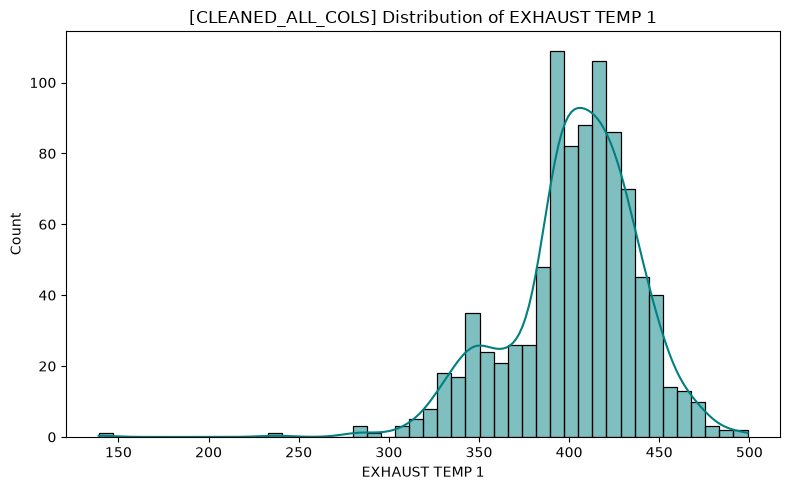

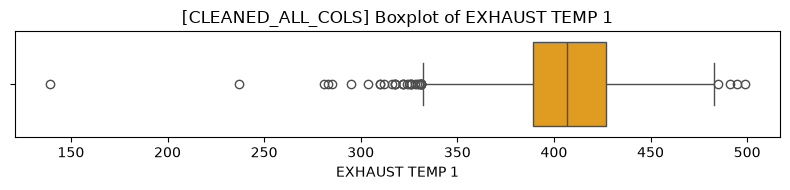

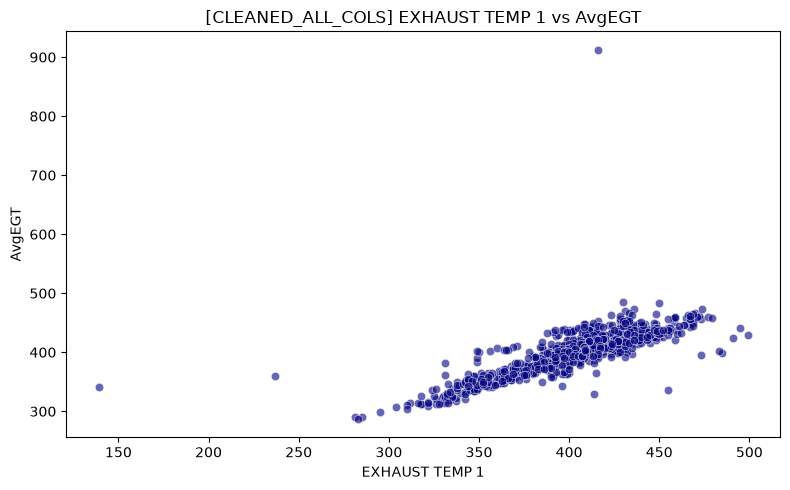

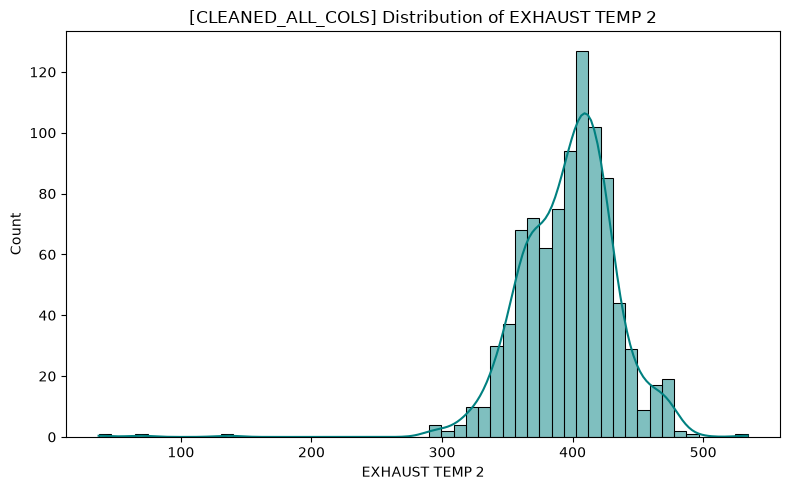

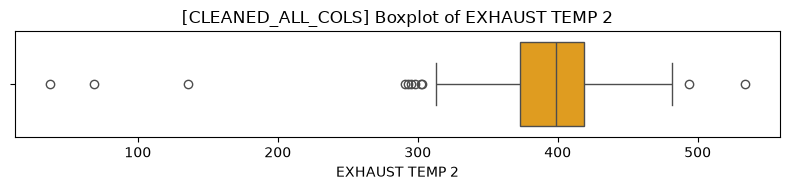

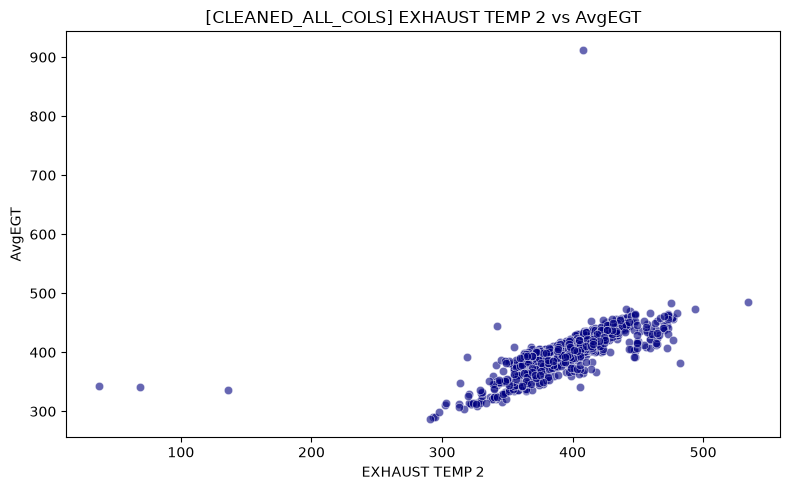

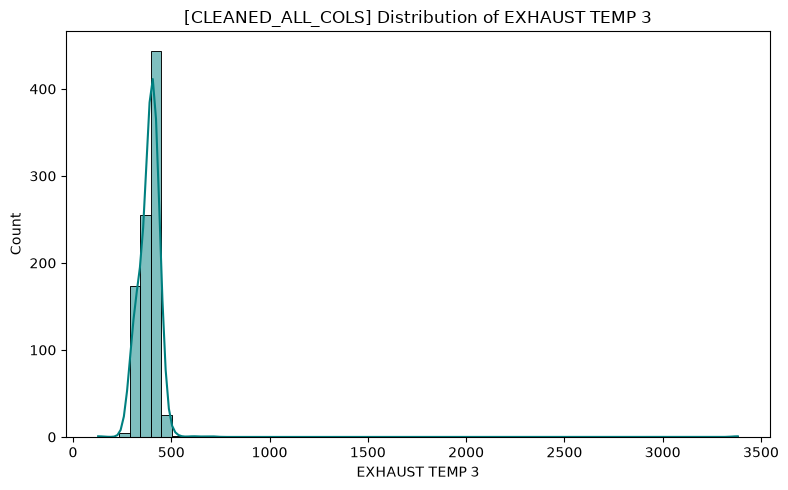

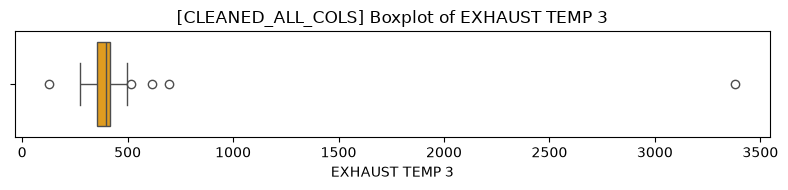

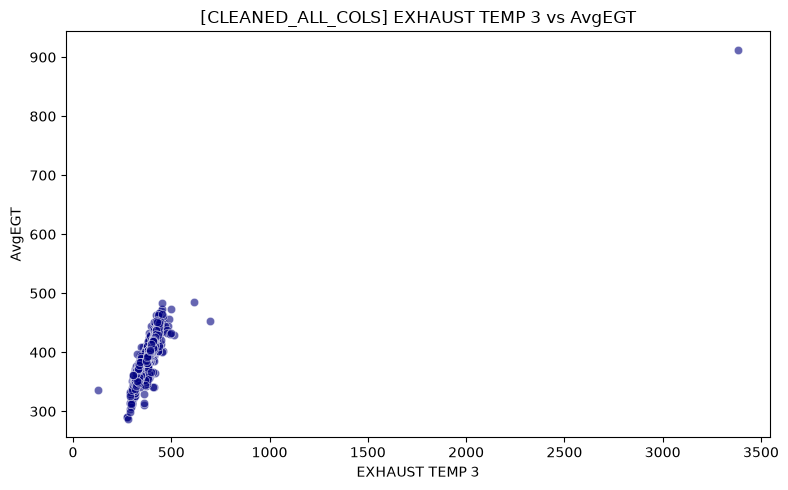

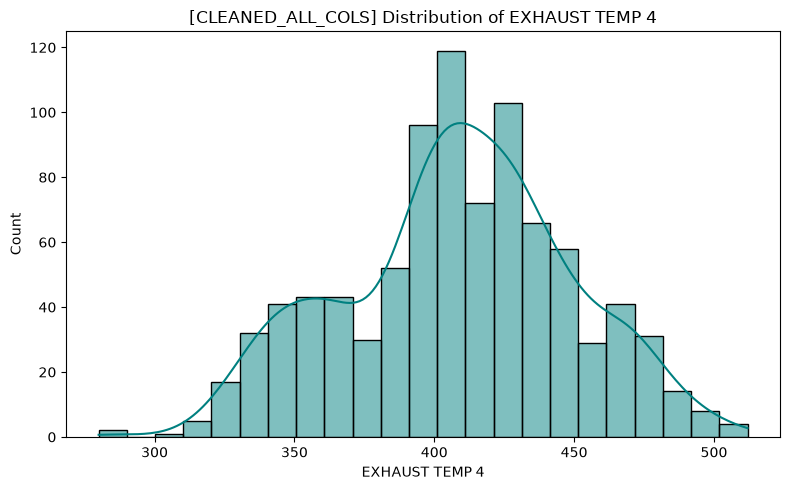

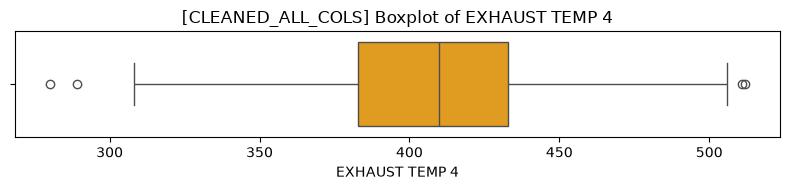

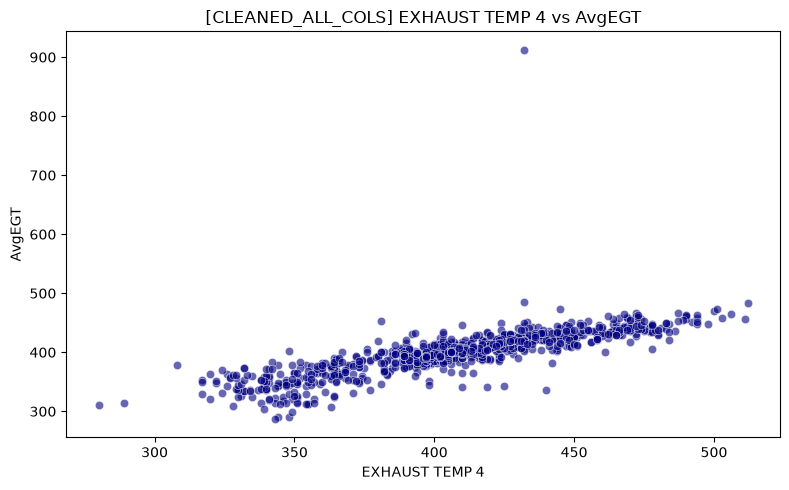

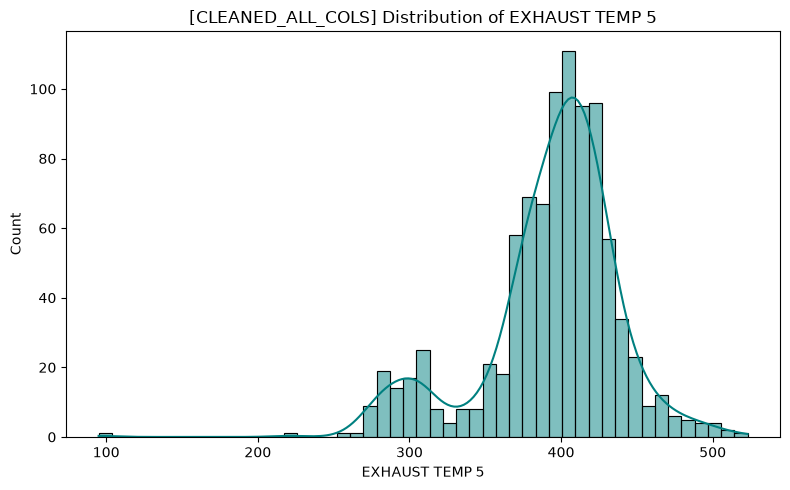

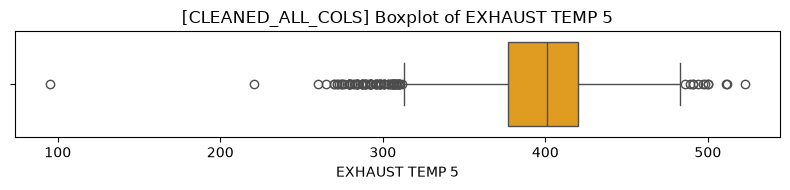

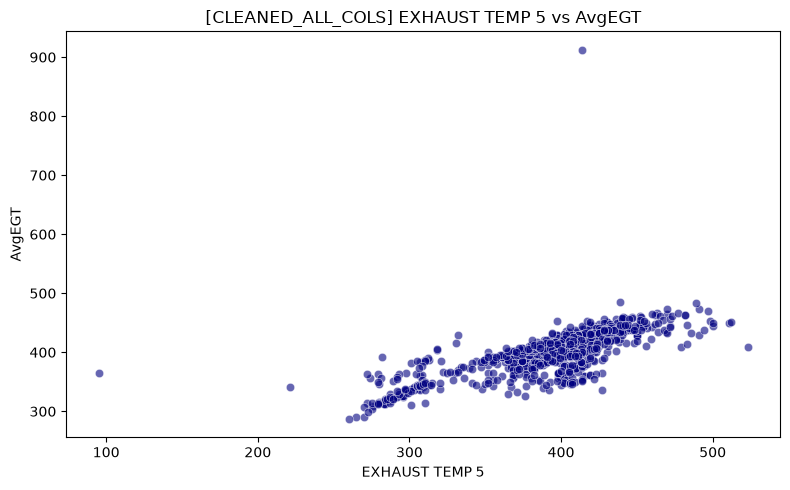

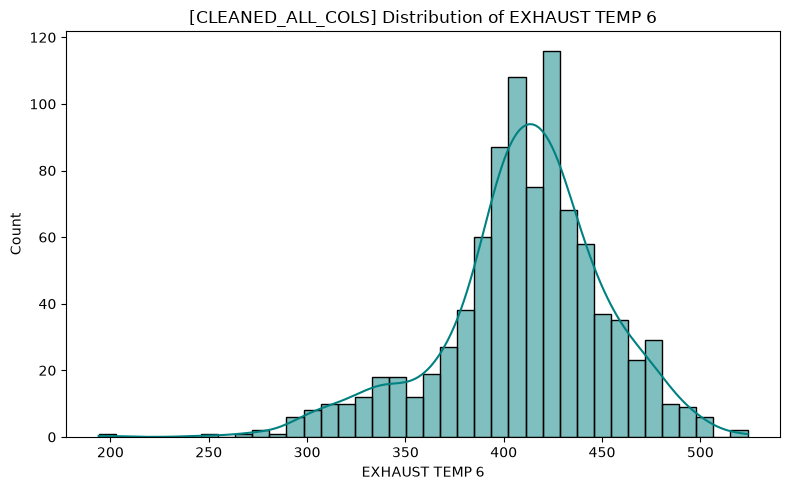

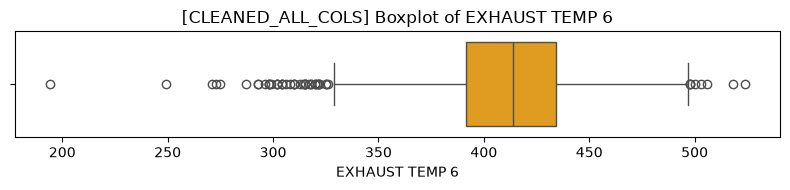

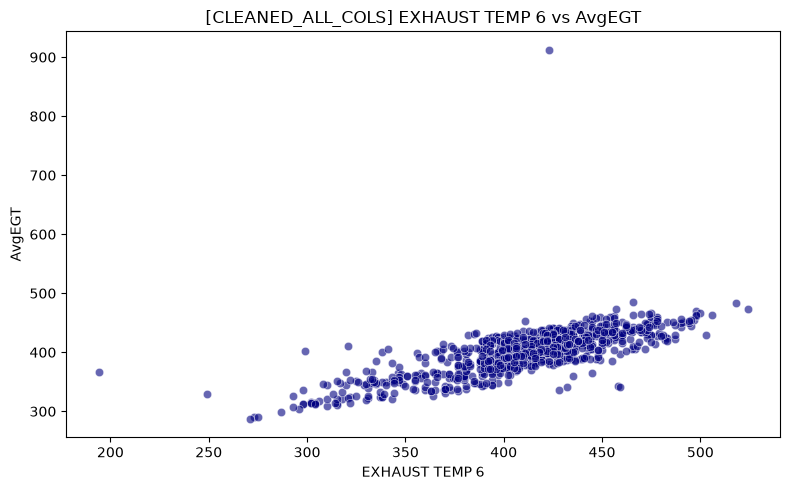

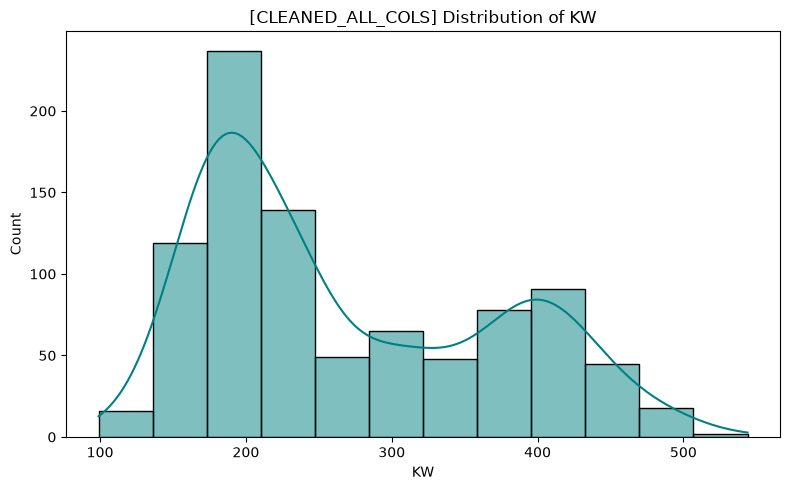

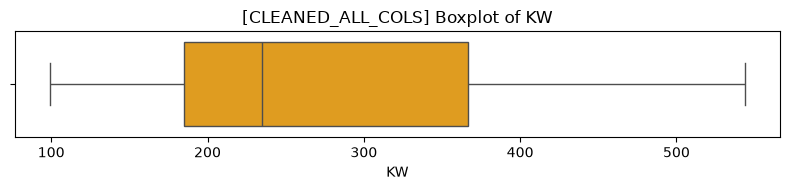

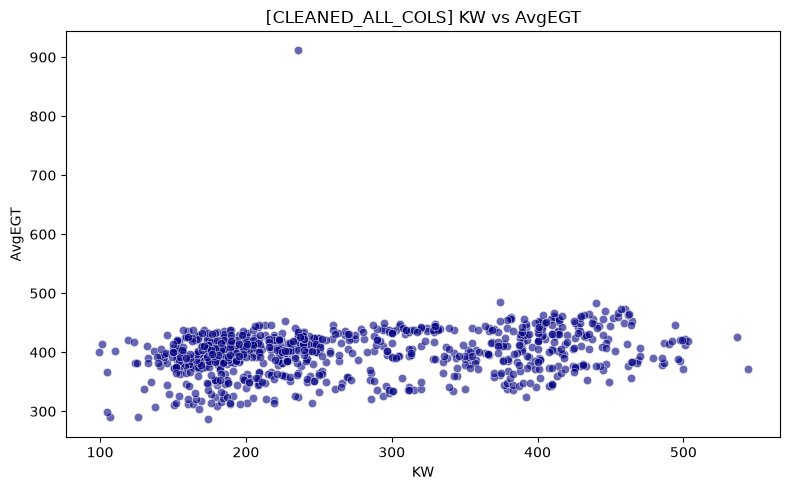

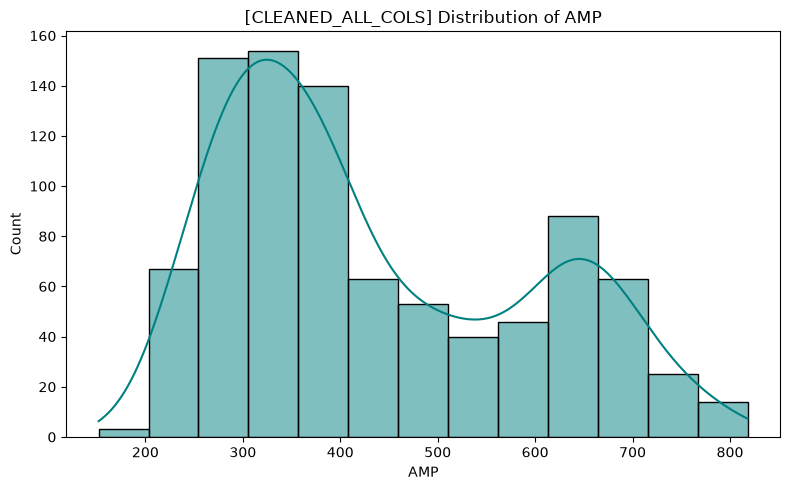

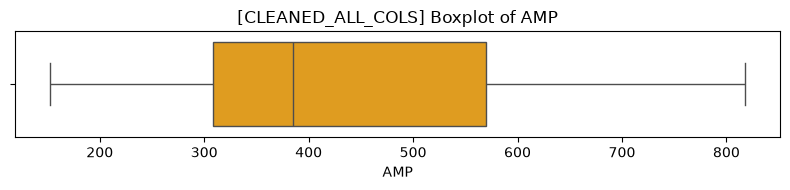

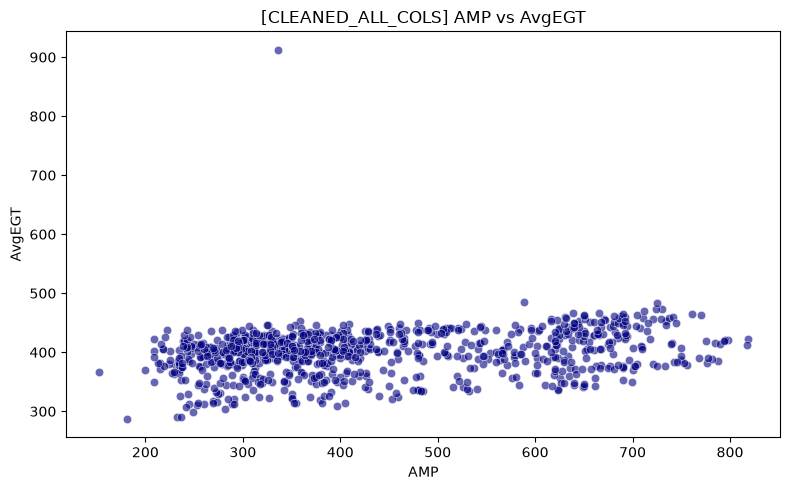

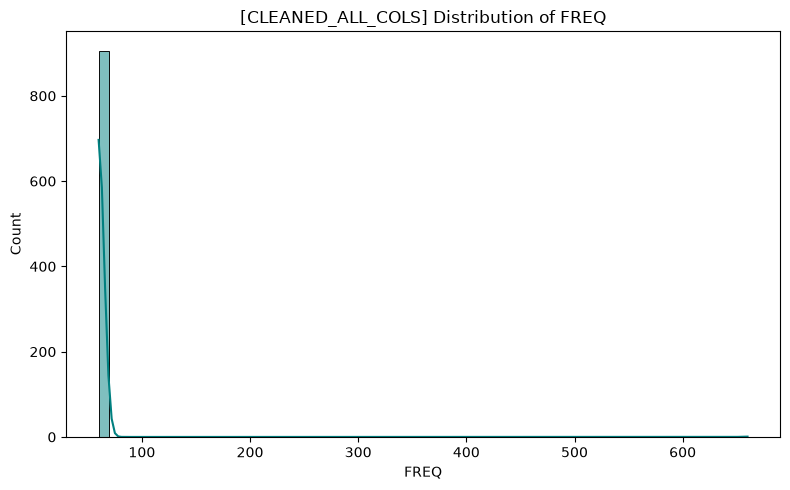

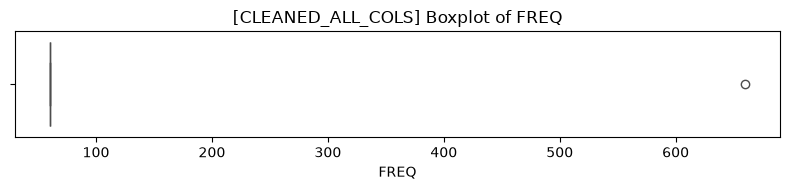

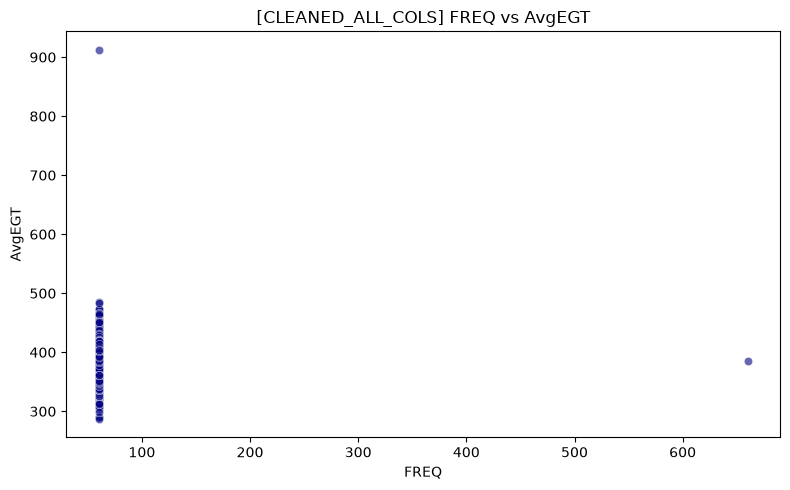

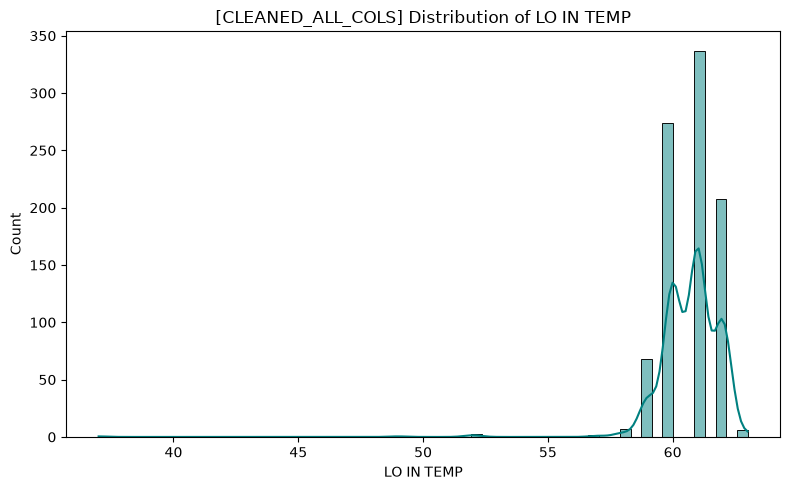

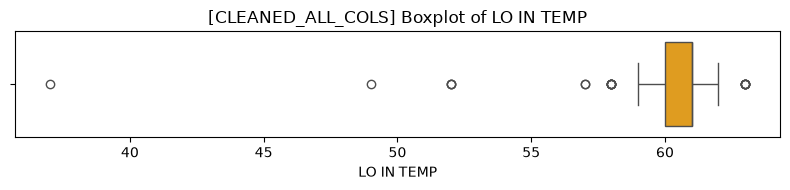

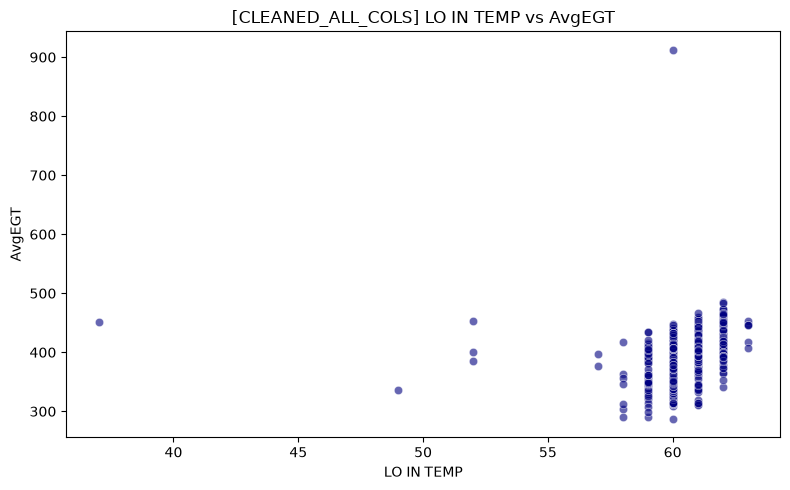

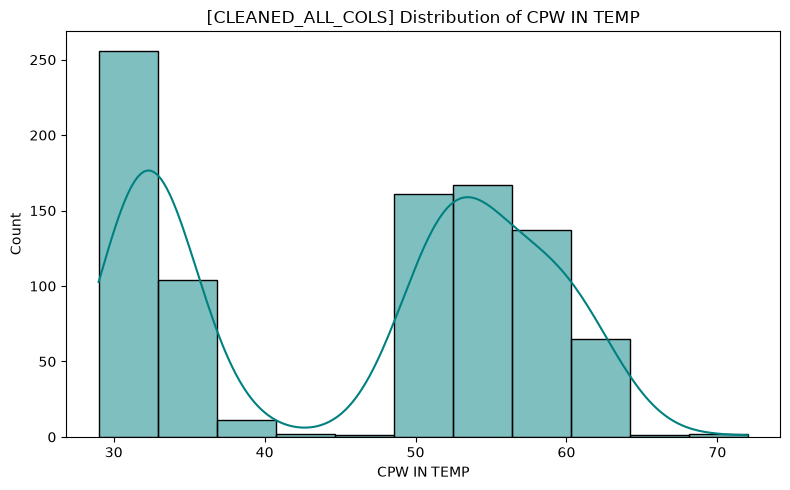

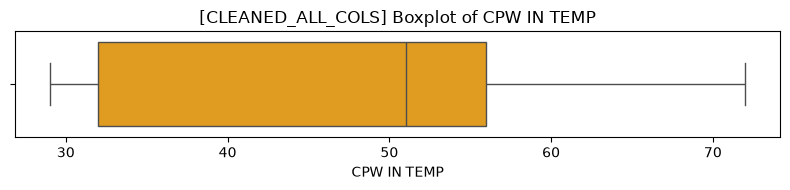

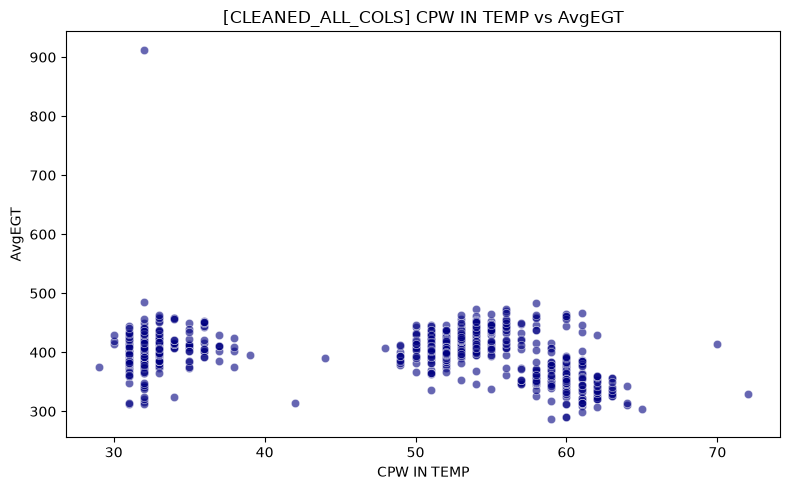

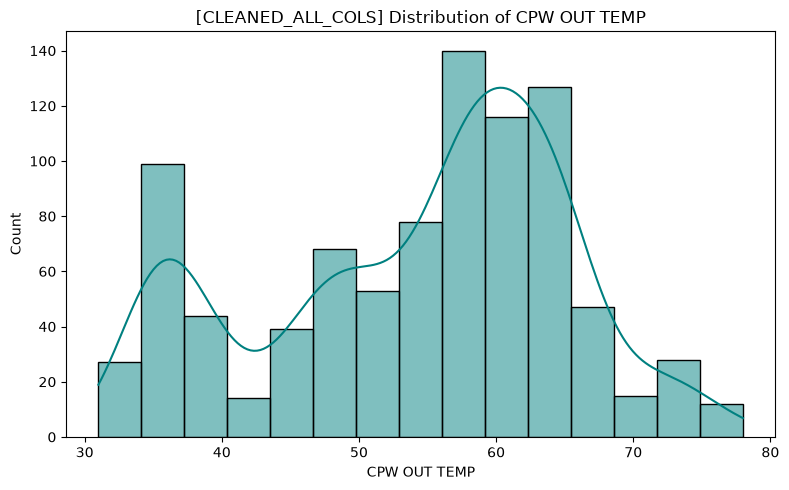

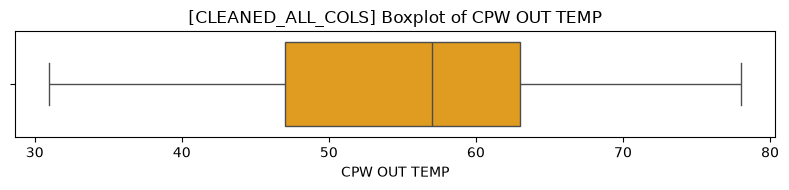

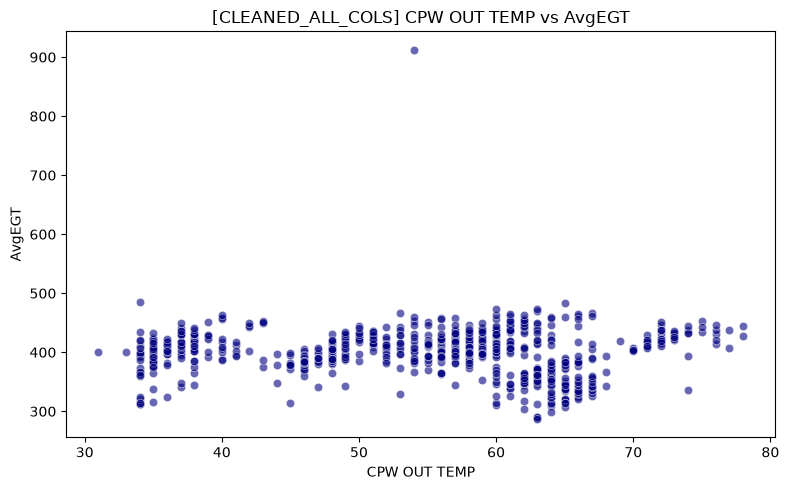

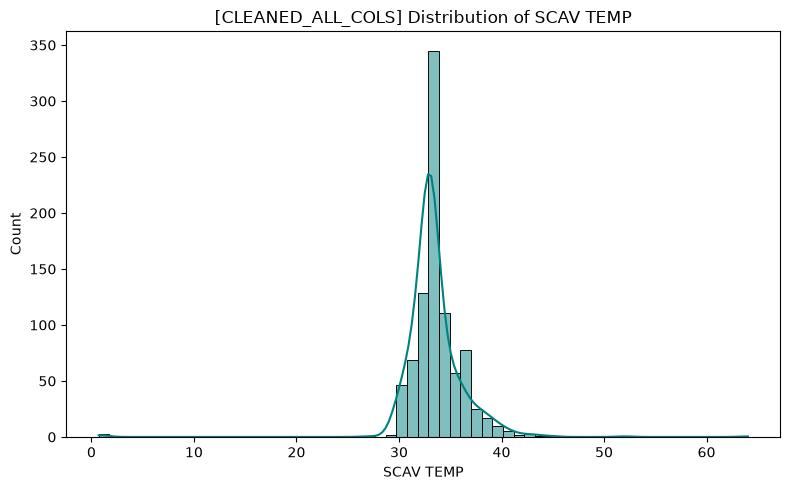

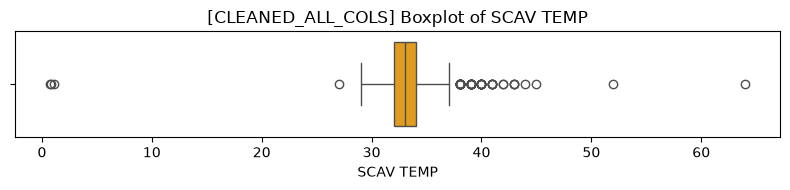

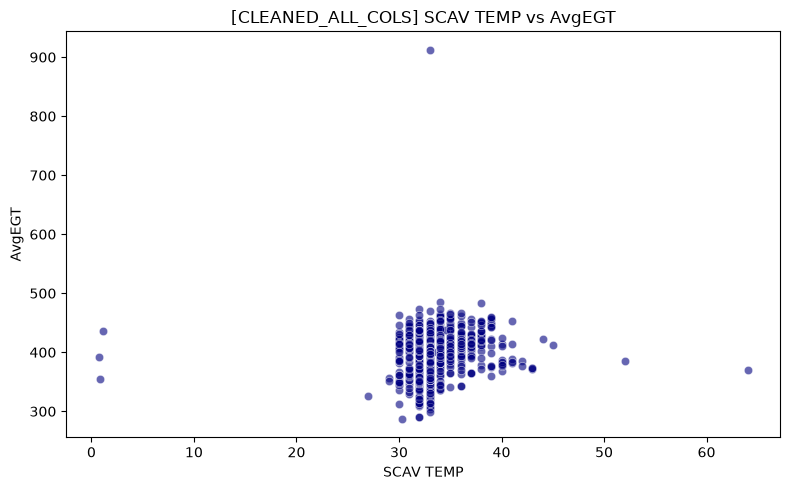

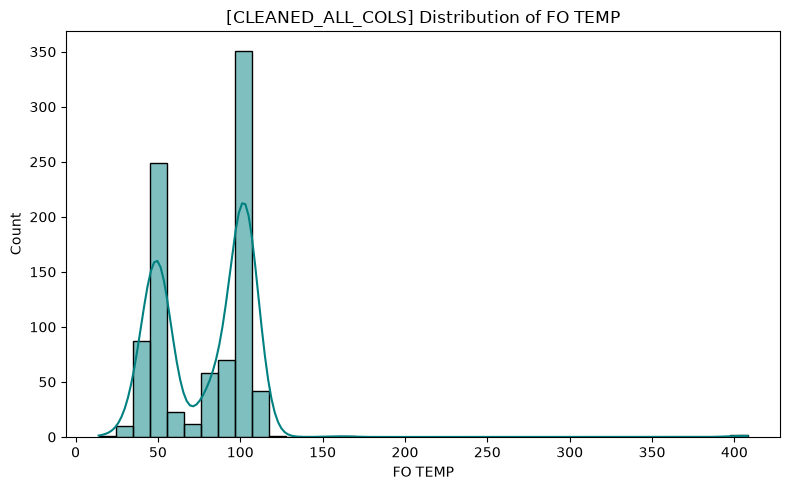

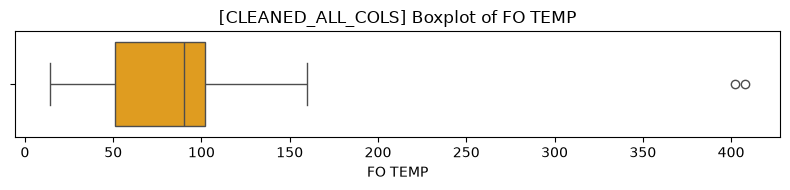

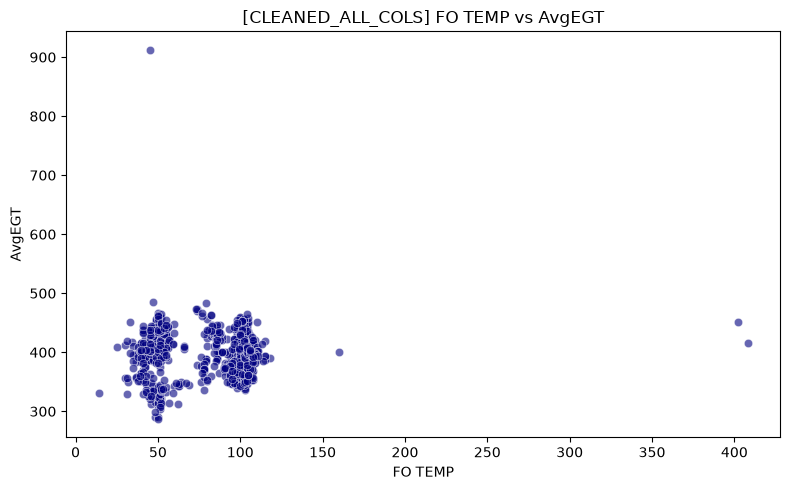

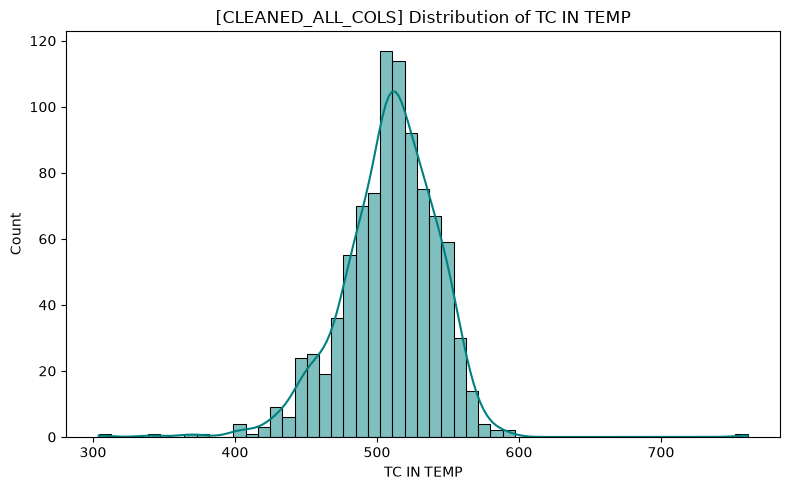

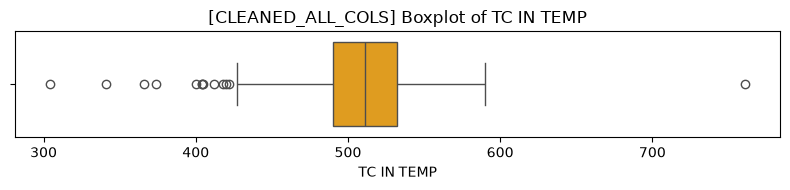

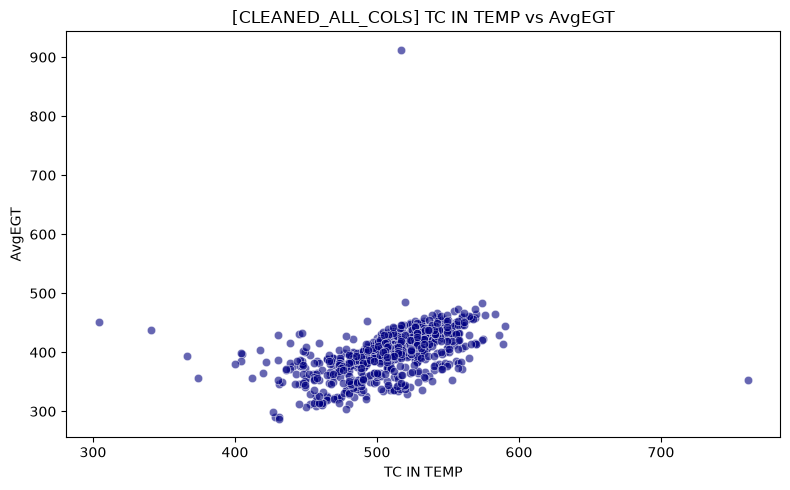

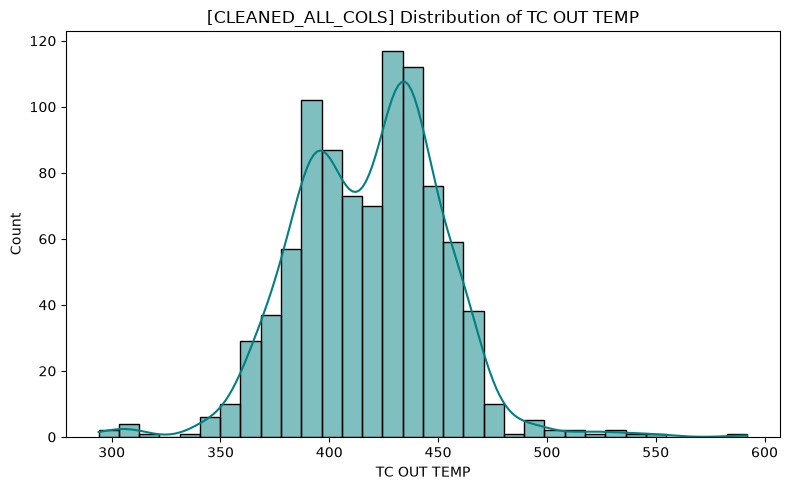

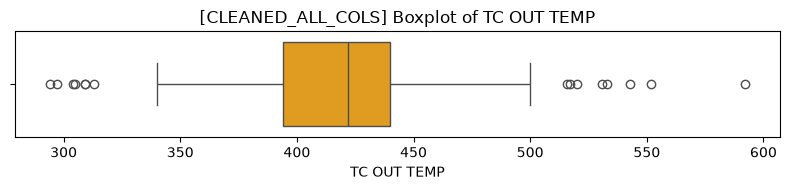

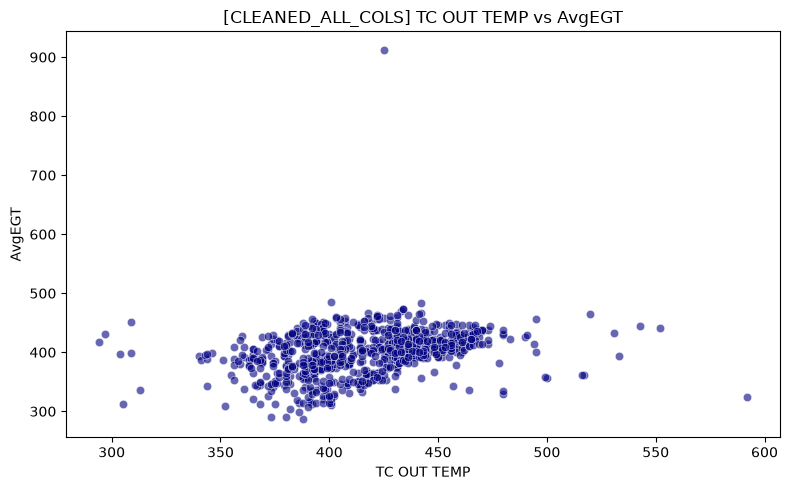

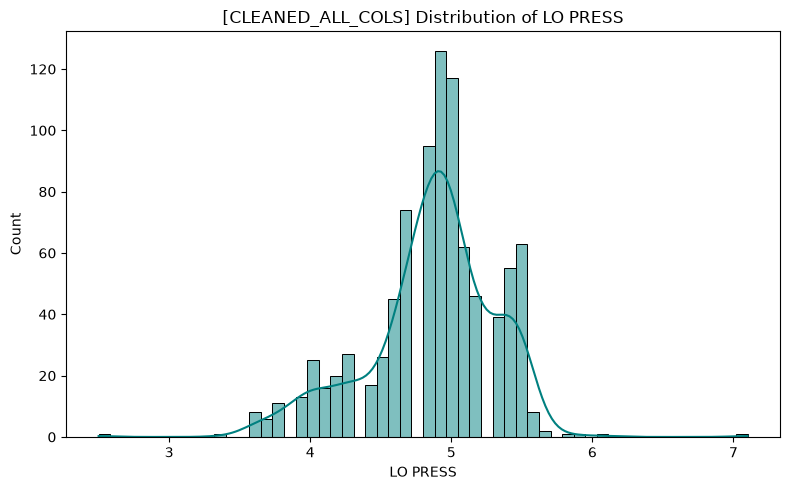

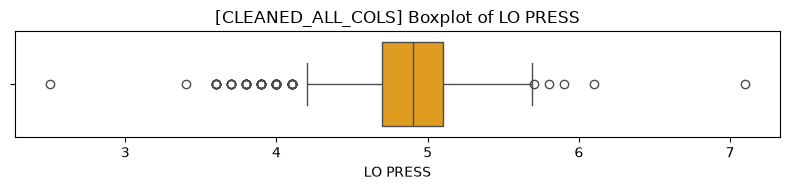

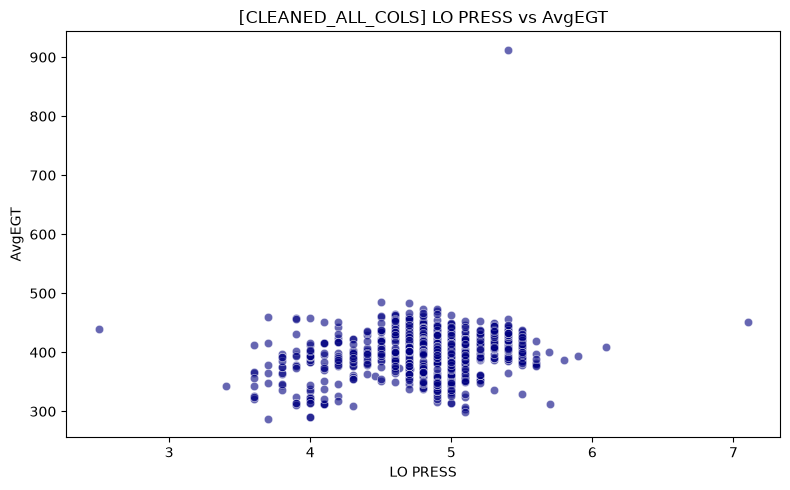

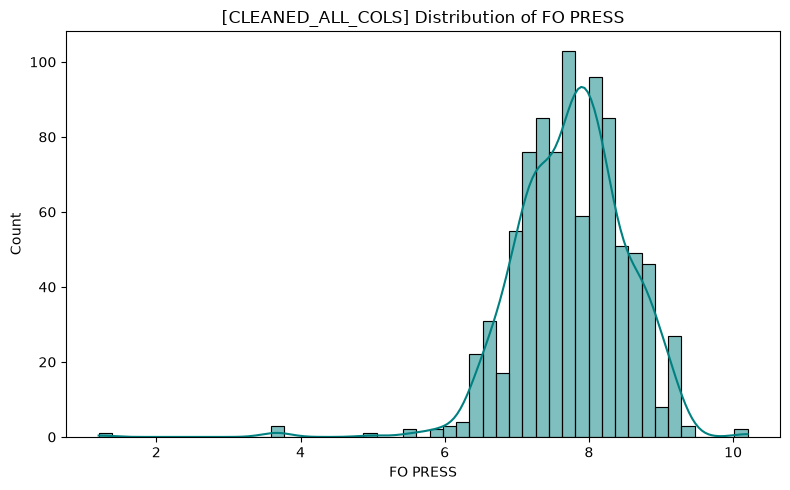

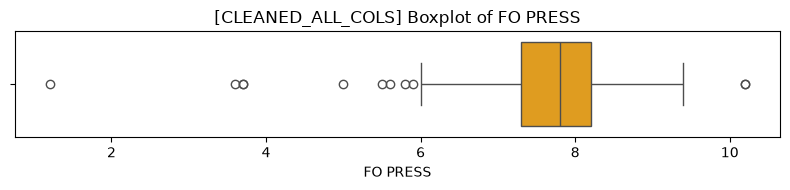

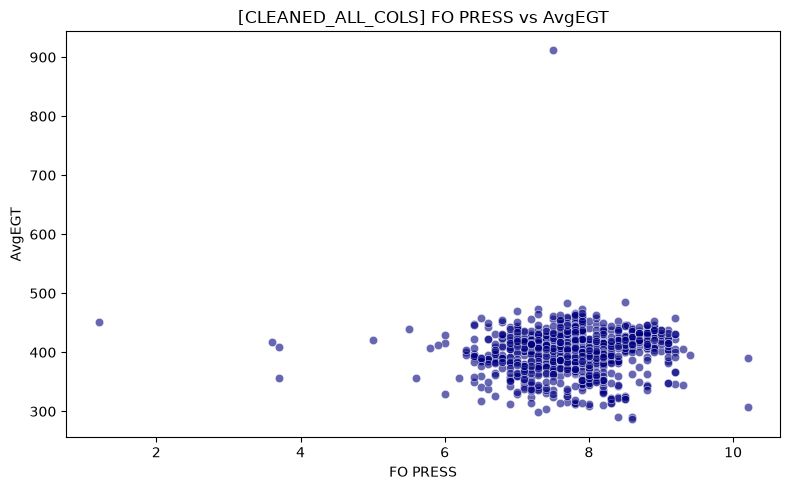

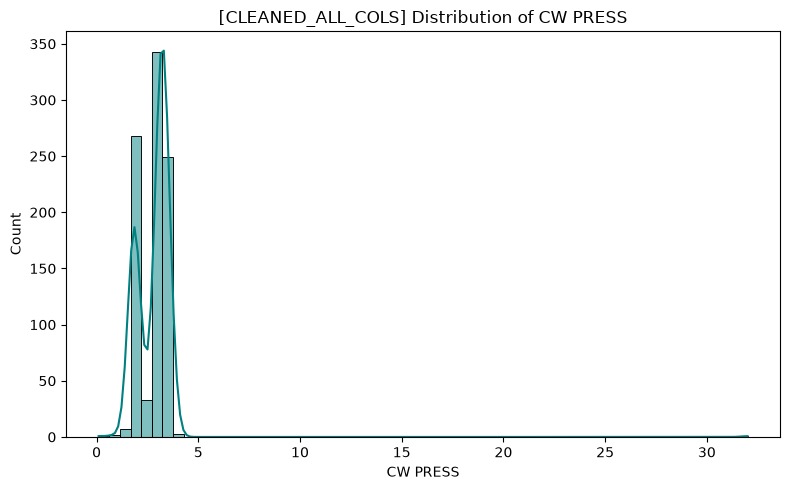

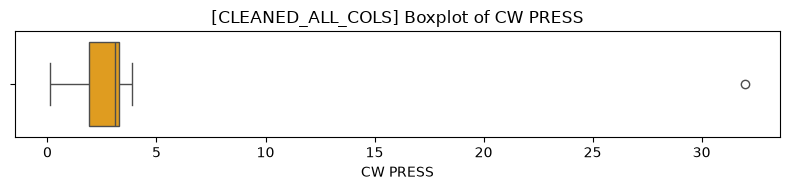

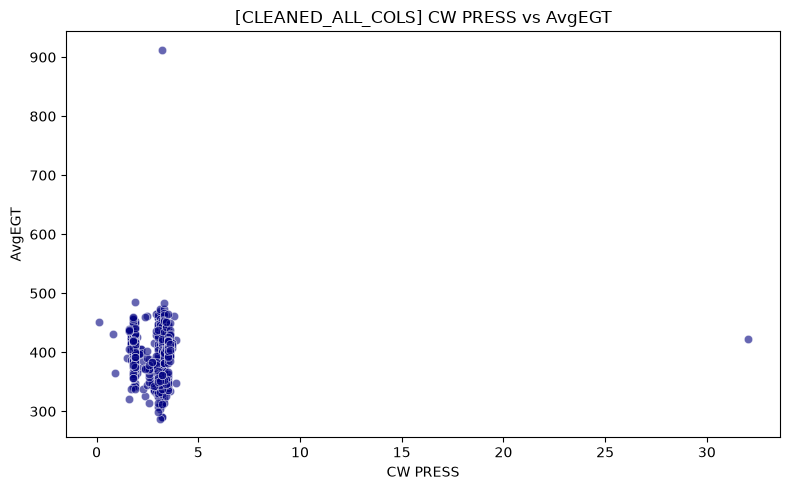

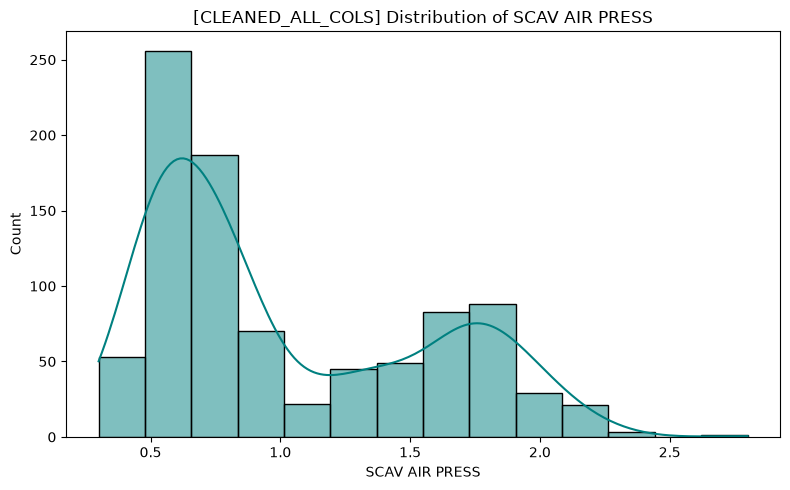

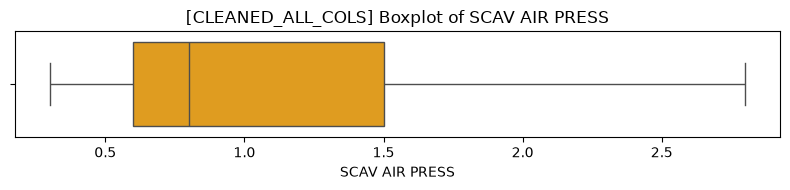

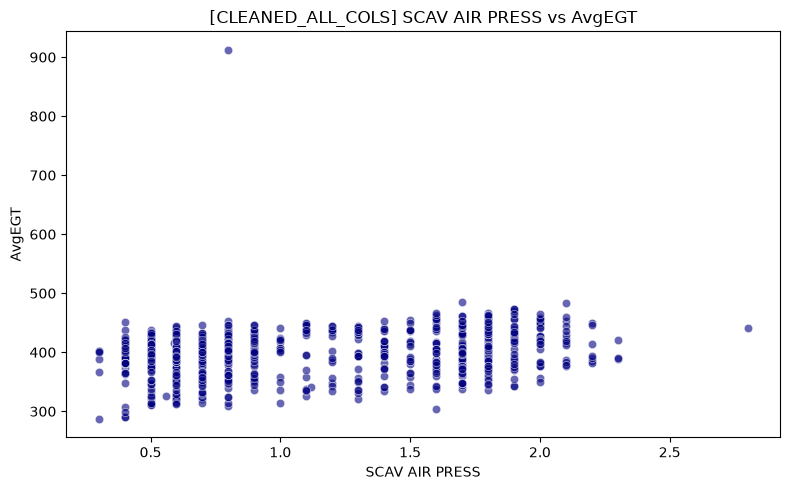

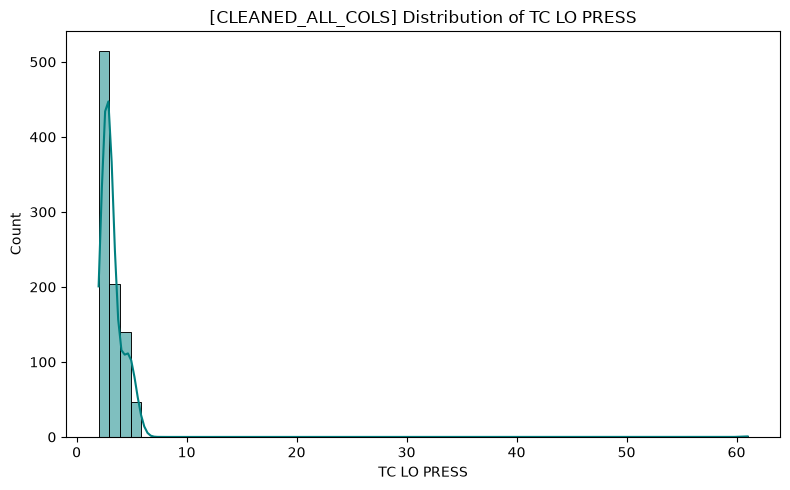

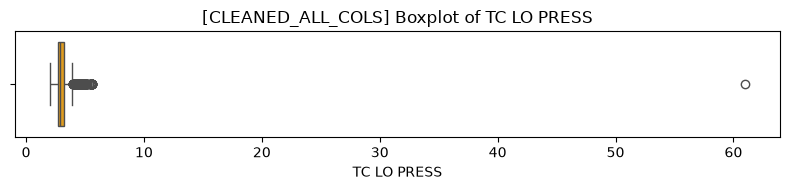

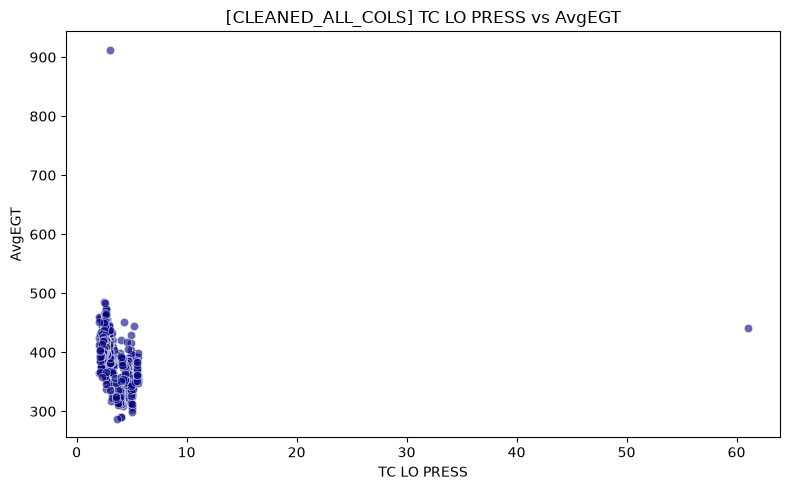

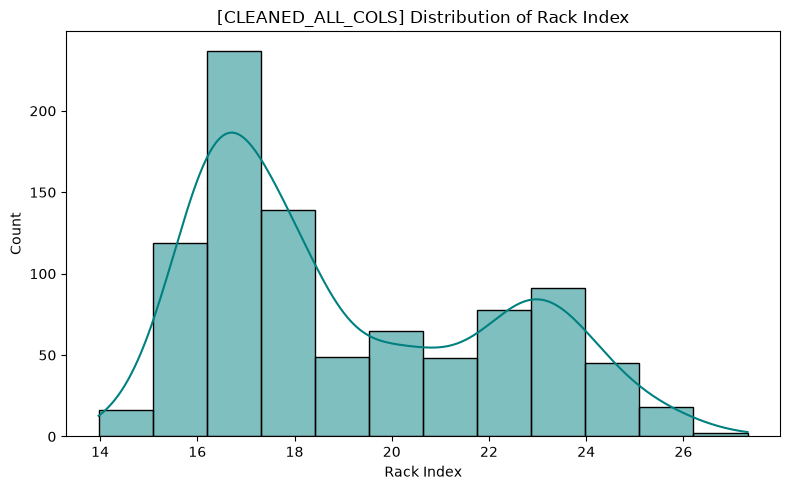

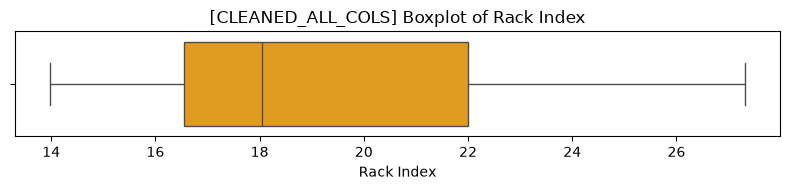

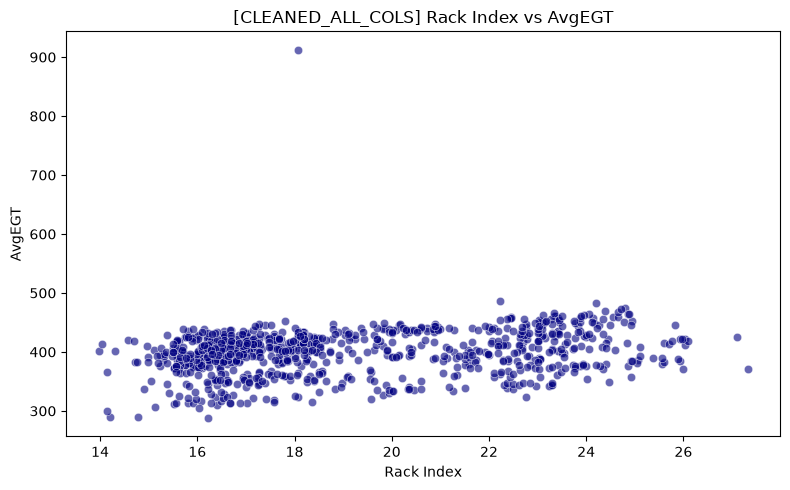

All plots rendered inline successfully!


In [3]:
def generate_feature_loops_inline(df, prefix=""):
    features = [c for c in df.columns if c != TARGET_COL]
    
    print(f"Generating plots for {len(features)} features...")
    
    for i, feature in enumerate(features):
        # 1. Feature Distribution
        plt.figure(figsize=(8, 5))
        sns.histplot(df[feature], kde=True, color='teal')
        plt.title(f'[{prefix.upper()}] Distribution of {feature}')
        plt.tight_layout()
        plt.show()
        
        # 2. Boxplot
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=df[feature], color='orange')
        plt.title(f'[{prefix.upper()}] Boxplot of {feature}')
        plt.tight_layout()
        plt.show()
        
        # 3. Scatter vs Target
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x=feature, y=TARGET_COL, alpha=0.6, color='navy')
        plt.title(f'[{prefix.upper()}] {feature} vs {TARGET_COL}')
        plt.tight_layout()
        plt.show()

generate_feature_loops_inline(df_cleaned_all_cols, prefix="Cleaned_All_Cols")
print("All plots rendered inline successfully!")